# Método da Secante

## Ideia do método

No Método da Secante, a derivada é aproximada pelo quociente das diferenças:

$$
f'(x_k)\approx\frac{f(x_k)-f(x_{k-1})}{x_k-x_{k-1}}
$$

A fórmula iterativa é

$$
x_{k+1}=x_k-\frac{f(x_k)}{f(x_k)-f(x_{k-1})}(x_k-x_{k-1})
$$


## Algoritmo

In [1]:
def secante(f,x0,x1,eps1=1e-3,eps2=1e-3,kmax=100):
    for k in range(kmax):
        x2=x1-(f(x1)/(f(x1)-f(x0)))*(x1-x0)
        if abs(f(x2))<eps1 or abs(x2-x1)<eps2:
            return x2
        x0,x1=x1,x2
    return x2


## Exemplo 1

$$
f(x)=x^2+x-6,
\qquad x_0=1.5,
\qquad \varepsilon_1=\varepsilon_2=10^{-4}.
$$

In [2]:
f=lambda x:x**2+x-6

x=secante(f,1.5,1.7,1e-4,1e-4)
print(f"x = {x:.8f}")
print(f"f(x) = {f(x):.8e}")

x = 1.99998395
f(x) = -8.02642943e-05


## Exemplo 2

$$
f(x)=x^3-9x+3,
\qquad x_0=1.5,
\qquad \varepsilon_1=\varepsilon_2=10^{-4}.
$$

In [8]:
f=lambda x:x**3-9*x+3

x=secante(f,0,1,5e-4,5e-4)
print(f"x = {x:.8f}")
print(f"f(x) = {f(x):.8e}")

x = 0.33763462
f(x) = -2.22206355e-04


## Exercício

$$
f(x)=x^2-5,
\qquad x_0=2,
\qquad \varepsilon_1=\varepsilon_2=10^{-4}.
$$

In [4]:
f=lambda x:x**2-5

x=secante(f,2,3,1e-4,1e-4)
print(f"x = {x:.8f}")
print(f"f(x) = {f(x):.8e}")

x = 2.23606793
f(x) = -2.28822991e-07


## Análise da Convergência

In [5]:
def secante_historico(f,x0,x1,eps1=1e-3,eps2=1e-3,kmax=100):
    ks=[]
    xhist=[x0,x1]
    fhist=[f(x0),f(x1)]
    dx=[None,abs(x1-x0)]
    for k in range(1,kmax+1):
        x2=x1-(f(x1)/(f(x1)-f(x0)))*(x1-x0)
        ks.append(k)
        xhist.append(x2)
        fhist.append(f(x2))
        dx.append(abs(x2-x1))
        if abs(f(x2))<eps1 or abs(x2-x1)<eps2:
            break
        x0,x1=x1,x2
    return ks,xhist,fhist,dx

## Visualização da Convergência

In [6]:
f = lambda x: x**2 - 5

k, x, fx, dx = secante_historico(
    f,
    2,
    2.5,
    eps1=1e-4,
    eps2=1e-4
)

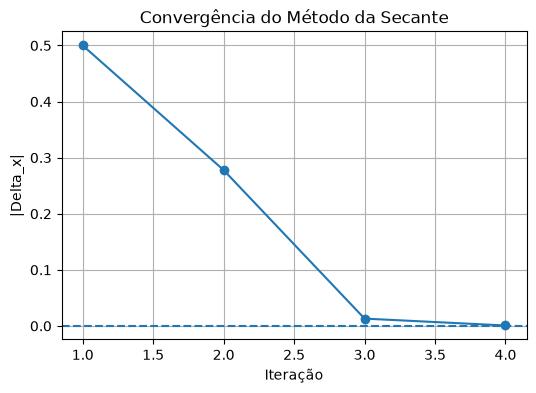

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(len(dx)), dx, marker="o")
plt.axhline(1e-4, linestyle="--")
plt.xlabel("Iteração")
plt.ylabel("|Delta_x|")
plt.title("Convergência do Método da Secante")
plt.grid(True)
plt.show()